# Transformation to OpenFOAM Code (Simple)

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_jax.fvm.solver_jax import Settings
from zoomy_core.model.models.shallow_water import ShallowWaterEquations

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct
import zoomy_core.misc.misc as misc
from zoomy_core.transformation.to_openfoam import FoamModel
import zoomy_core.mesh.mesh as petscMesh


## Model definition

In [2]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="wall"),
        BC.Wall(tag="inflow"),
        BC.Wall(tag="outflow"),
    ]
)

def custom_ic(x):
    Q = np.zeros(3, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model = ShallowWaterEquations(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
)

# the mesh is necessary to connect the boundary conditions to the mesh tags
main_dir = misc.get_main_directory()
mesh = petscMesh.Mesh.from_gmsh(
    os.path.join(main_dir, "meshes/channel_quad_2d/mesh.msh")
)

## Sympy Model

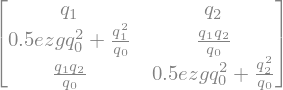

In [3]:
model.flux()

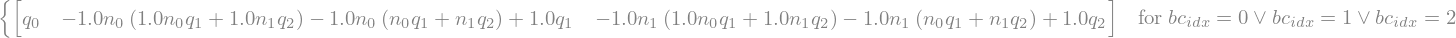

In [4]:
model.print_boundary_conditions()

## Code transformation

In [5]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5"))
FoamModel.write_code(model, settings)

2026-01-10 11:32:37.509 | WARNING  | zoomy_core.misc.misc:__init__:194 - No 'clean_directory' attribute found in output Zstruct. Default: False
2026-01-10 11:32:37.510 | WARNING  | zoomy_core.misc.misc:__init__:197 - No 'snapshots' attribute found in output Zstruct. Default: 2


'/home/ingo/Git/Zoomy/outputs/trafo/.foam_interface/Model.H'

## Check the output

In [6]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.foam_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include "List.H"
#include "vector.H"
#include "scalar.H"
#include <vector>
#include <string>


struct Model {

    // --- Constants ---
    static constexpr int n_dof_q    = 3;
    static constexpr int n_dof_qaux = 2;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 3;

    // --- Helpers ---
    static const std::vector<std::string> get_boundary_tags() { return { "inflow", "outflow", "wall" }; }

    // --- Kernels ---

    static inline Foam::List<Foam::List<Foam::scalar>> flux(
        const Foam::List<Foam::scalar>& Q,
        const Foam::List<Foam::scalar>& Qaux)
    {
        auto res = Foam::List<Foam::List<Foam::scalar>>(3, Foam::List<Foam::scalar>(2, 0.0));
    Foam::scalar t0 = 0.5*1.0*9.81*Foam::pow(Q[0], 2);
    Foam::scalar t1 = (1.0 / Foam::pow(Q[0], 1));
    Foam::scalar t2 = Q[1]*Q[2]*t1;
    res[0][0] = Q[1];
    res[0][1] = Q[2];
    res[1][0] = Foam::pow(Q[1], 2)*t1 + t0;
    res[1][1] = t2;
    res[2][0] = t2;
    res